# Microstrip Arrangment Potential Distribution

## Initialization

In [1]:
# import required libraries
########################################################################################
# calculations
import time
import os
import pandas as pd
import numpy as np

# plotting
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# reload
from importlib import reload
from typing import *

# import custom files
#############################################################################################
# import helper functions
import helper_functions as F
# import custom environmnet
from MicroStripArrangementEnv import MicroStripArrangementEnv as msaEnv
reload(F)

# import RL
###############################################################################################
# import stable baselines 3 algorithm
from stable_baselines3 import A2C,SAC
# import stable baselines 3 functions
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.vec_env import DummyVecEnv #, SubprocVecEnv
# from stable_baselines3.common.noise import NormalActionNoise
# from stable_baselines3.common.noise import OrnsteinUhlenbeckActionNoise
# from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold

# import pytorch for setting policy kwargs
import torch as th

## File Locations

In [2]:
# create folders to save models and log files
models_dir_root = "training/models"
logdir_root = "training/logs"
imgdir_root = "training/images"
if not os.path.exists(models_dir_root):
    os.makedirs(models_dir_root)
    
if not os.path.exists(logdir_root):
    os.makedirs(logdir_root)

if not os.path.exists(imgdir_root):
    os.makedirs(imgdir_root)

In [3]:
# env=msaEnv(V0=1,hw_arra=0.002,ht_arra=0.002,ht_subs=0.00079,hw_micrstr=0.0002,ht_micrstr=0,er_1=1,er_2=2.2,num_fs=20,num_pts=20)
# from stable_baselines3.common.env_checker import check_env
# check_env(env, warn=True)

## Train

### Case D

In [11]:
# hw_micrstr = 0.05e-3
# # read true values 
# df_D = pd.read_csv('NominalGPtsCaseDCase2_1.csv')
# df_D = df_D[df_D['g_ptsx'] >= hw_micrstr]
# df_D = df_D.drop_duplicates(['g_ptsx'])

# x_true = np.array(df_D['g_ptsx']) 
# y_true = np.array(df_D['g_ptsy'])

# x_true = np.insert(x_true,0,0)
# y_true = np.insert(y_true,0,1)
# y_true[-1] = 0

In [5]:
# # read true values 
# df_D = pd.read_csv('GptsTrueCaseD.csv')
# x_true = np.array(df_D['x']) 
# y_true = np.array(df_D['Nom'])

### SAC

In [ ]:
# setting up the MSA env with number of fs_coeff = 20
env_D = msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=2.76e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=12.9,num_fs=500,num_pts=20)

# # number of parallel environments
# num_envs = 8

# # VecEnv for separate-process parallelization
# vectorized_env = DummyVecEnv([lambda: msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=1.38e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=12.9,num_fs=20,num_pts=20)
#                               for _ in range(num_envs)])

# set a different environment for evaluation
eval_env = msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=2.76e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=12.9,num_fs=500,num_pts=20)

In [ ]:
# Specify directories
#################################################################################################
models_dir = os.path.join(models_dir_root,'Case_D','SAC')
logdir = os.path.join(logdir_root,'Case_D','SAC')
imgdir = os.path.join(imgdir_root,'Case_D','SAC')

for dir in [models_dir,logdir,imgdir]:
    if not os.path.exists(dir):
        os.makedirs(dir)


# Specify hyperparameters
##################################################################################################
# setting nn architecture
policy_kwargs = dict(activation_fn=th.nn.ReLU,
                     net_arch=[256, 256])
# hyperparams = {
#     'ent_coef': 0.01,            # Entropy coefficient
#     'learning_rate': 0.0007,     # Learning rate
#     'gae_lambda': 0.95,          # Generalized Advantage Estimation lambda
#     'gamma': 0.99,               # Discount factor
#     'max_grad_norm': 0.5,        # Maximum gradient norm

# }
# set the total steps to be taken during model learning
TIMESTEPS = 20000 # one hundred thousand timesteps

# verbose = 1 prints details
#####################################################################################################
# model = A2C("MlpPolicy", 
#              vectorized_env,  
#              verbose=0, 
#              policy_kwargs=policy_kwargs,
#              tensorboard_log=os.path.join(logdir,'A2C'),
#              **hyperparams)

model = SAC("MlpPolicy", 
             env_D,  
             verbose=0, 
             policy_kwargs=policy_kwargs,
             ent_coef = 0.05,
             tensorboard_log=os.path.join(logdir,'SAC'))

model,caseD_res,action_caseD = F.train_model('SAC',model,env_D,'Case_D',TIMESTEPS,x_true,y_true,models_dir,imgdir)

# print action
print(f'Action SAC: {action_caseD}')

# Evaluate the trained agent
######################################################################################################
mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=10)
print(f"Mean reward: {mean_reward} +/- {std_reward:.2f}")

In [ ]:
# plot
######################################################################################################
env_D = msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=2.76e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=12.9,num_fs=500,num_pts=10)
obs_space,_ss = env_D.reset()
action_caseD, _states = model.predict(obs_space)
g_ptsx,g_ptsy,control_points = env_D.g_points_cubic_bezier(action_caseD)
print(f'Montone Decreasing: {env_D.monotonically_decreasing(g_ptsy)}, Convex: {env_D.is_convex(g_ptsy)}')

g_ptsx = np.insert(g_ptsx,0,0)
g_ptsy = np.insert(g_ptsy,0,1)

Energy_pred = env_D.energy(env_D.potential_coeff(g_ptsy[2:-1],g_ptsx[2:-1]))
Energy_nom = env_D.energy(env_D.potential_coeff(y_true[2:-1],x_true[2:-1]))
Min_Energy = Energy_pred < Energy_nom

print(f'Action:{action_caseD}')
print(f'Prediction Energy:{Energy_pred}')

# Plot 
plt.figure(figsize=(10, 6))
plt.plot(g_ptsx*1000, g_ptsy, color = 'green',label='Prediction')
plt.plot(x_true*1000, y_true, color = 'blue',label='Nominal')
plt.scatter(control_points[:,0]*1000,control_points[:,1],color='red',label='control points')
# plt.plot(env_D.x*1000, env_D.line_threshold, color = 'brown',label='Threshold')
plt.title(f'Case D er2 = 12.9, SAC Predicted G Points=> Prediction Energy:{Energy_pred}, Nominal Energy:{Energy_nom}, Less Than Nominal:{Min_Energy}')
plt.xlabel('Length [mm]')
plt.ylabel('Potential [V]')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
SAC_res = {'g_ptsx':g_ptsx,
           'g_ptsy':g_ptsy
           }
(pd.DataFrame(SAC_res)).to_csv('training/cubic_bezier_curve_CaseD_SAC.csv')

### A2C

In [ ]:
# setting up the MSA env with number of fs_coeff = 20
env_D = msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=2.76e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=12.9,num_fs=500,num_pts=20)

# # number of parallel environments
# num_envs = 8

# # VecEnv for separate-process parallelization
# vectorized_env = DummyVecEnv([lambda: msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=1.38e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=12.9,num_fs=20,num_pts=20)
#                               for _ in range(num_envs)])

# set a different environment for evaluation
eval_env = msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=2.76e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=12.9,num_fs=500,num_pts=20)

#### Setup Model and Train

In [ ]:
# Specify directories
#################################################################################################
models_dir = os.path.join(models_dir_root,'Case_D','A2C')
logdir = os.path.join(logdir_root,'Case_D','A2C')
imgdir = os.path.join(imgdir_root,'Case_D','A2C')

for dir in [models_dir,logdir,imgdir]:
    if not os.path.exists(dir):
        os.makedirs(dir)


# Specify hyperparameters
##################################################################################################
# setting nn architecture
policy_kwargs = dict(activation_fn=th.nn.ReLU,
                     net_arch=[256, 256])
# hyperparams = {
#     'ent_coef': 0.01,            # Entropy coefficient
#     'learning_rate': 0.0007,     # Learning rate
#     'gae_lambda': 0.95,          # Generalized Advantage Estimation lambda
#     'gamma': 0.99,               # Discount factor
#     'max_grad_norm': 0.5,        # Maximum gradient norm

# }

# set the total steps to be taken during model learning
TIMESTEPS = 20000 # one hundred thousand timesteps

# verbose = 1 prints details
#####################################################################################################
# model = A2C("MlpPolicy", 
#              vectorized_env,  
#              verbose=0, 
#              policy_kwargs=policy_kwargs,
#              tensorboard_log=os.path.join(logdir,'A2C'),
#              **hyperparams)

model = A2C("MlpPolicy", 
             env_D,  
             verbose=0, 
             policy_kwargs=policy_kwargs,
             ent_coef = 0.05,
             tensorboard_log=os.path.join(logdir,'A2C'))

model,caseD_res,action_caseD = F.train_model('A2C',model,env_D,'Case_D',TIMESTEPS,x_true,y_true,models_dir,imgdir)

# print action
print(f'Action A2C: {action_caseD}')

# Evaluate the trained agent
######################################################################################################
mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=10)
print(f"Mean reward: {mean_reward} +/- {std_reward:.2f}")

#### Plot

Montone Decreasing: True, Convex: True
Prediction Energy:1.0074791387717262e-10


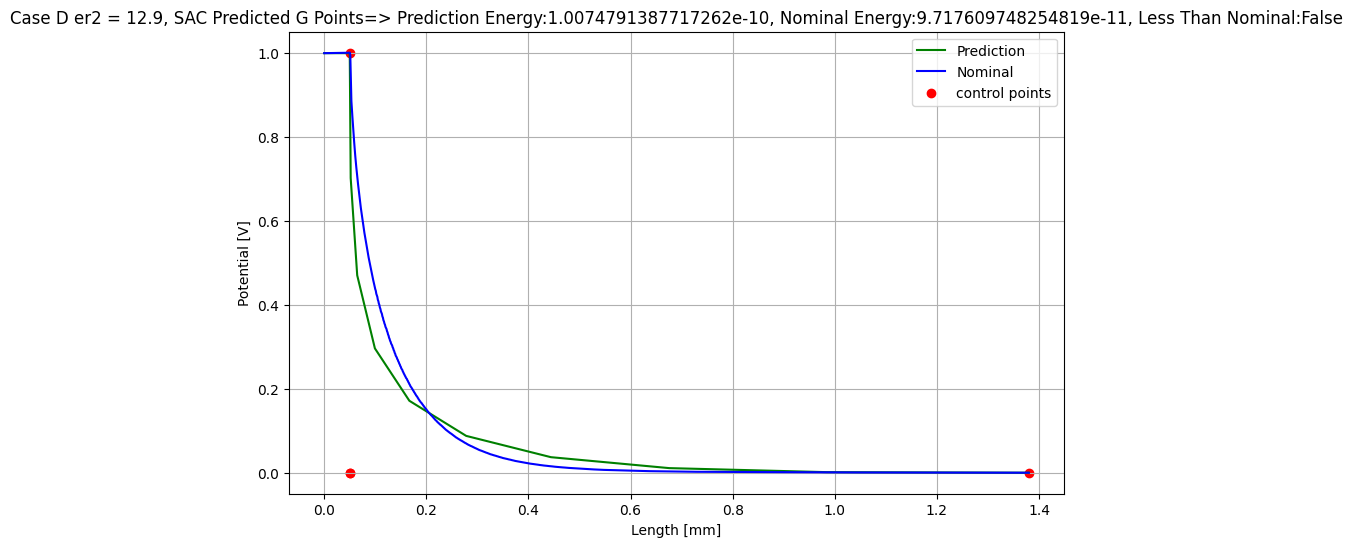

In [12]:
# plot
######################################################################################################
env_D = msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=2.76e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=12.9,num_fs=500,num_pts=53)
obs_space,_ss = env_D.reset()
# action_caseD, _states = model.predict(obs_space)
g_ptsx,g_ptsy,control_points = env_D.g_points_cubic_bezier(np.array([0,0,0,0]))
print(f'Montone Decreasing: {env_D.monotonically_decreasing(g_ptsy)}, Convex: {env_D.is_convex(g_ptsy)}')

g_ptsx = np.insert(g_ptsx,0,0)
g_ptsy = np.insert(g_ptsy,0,1)

Energy_pred = env_D.energy(env_D.potential_coeff(g_ptsy[2:-1],g_ptsx[2:-1]))
Energy_nom = env_D.energy(env_D.potential_coeff(y_true[2:-1],x_true[2:-1]))
Min_Energy = Energy_pred < Energy_nom

# print(f'Action:{action_caseD}')
print(f'Prediction Energy:{Energy_pred}')
print(f'Nominal Energy:{Energy_nom}')

# Plot 
plt.figure(figsize=(15, 10))
plt.plot(g_ptsx*1000, g_ptsy, color = 'green',label='Prediction')
plt.plot(x_true*1000, y_true, color = 'blue',label='Nominal')
plt.scatter(control_points[:,0]*1000,control_points[:,1],color='red',label='control points')
# plt.plot(env_D.x*1000, env_D.line_threshold, color = 'brown',label='Threshold')
# plt.title(f'Case D er2 = 12.9, SAC Predicted G Points=> Prediction Energy:{Energy_pred}, Nominal Energy:{Energy_nom}, Less Than Nominal:{Min_Energy}')
plt.xlabel('Length [mm]')
plt.ylabel('Potential [V]')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
A2C_res = {'g_ptsx':g_ptsx,
           'g_ptsy':g_ptsy
           }
(pd.DataFrame(A2C_res)).to_csv('training/cubic_bezier_curve_CaseD_A2C.csv')

In [ ]:
# fig = make_subplots(rows=1, cols=1,shared_xaxes=True)

# fig.add_trace(go.Scatter(x = x_true*1000,y =y_true, name = 'VL',marker=dict(color='red')),row=1, col=1)
# fig.add_trace(go.Scatter(x = g_ptsx*1000,y =g_ptsy, name = 'predL',marker=dict(color='blue')),row=1, col=1)

# fig.update_layout(height=400, width=600, title="Comparison Nominal and Calculated VL(x,y=c)",
#                 xaxis_title = 'x [mm]',
#                 yaxis_title = 'VD(x,y=c) [Volt]')
# fig.show()

### Case L

In [6]:
hw_micrstr = 0.05e-3
# read true values 
df_L = pd.read_csv('NominalGPtsCaseLCase2_1.csv')
df_L = df_L[df_L['g_ptsx'] >= hw_micrstr]
df_L = df_L.drop_duplicates(['g_ptsx'])

x_true = np.array(df_L['g_ptsx']) 
y_true = np.array(df_L['g_ptsy'])

x_true = np.insert(x_true,0,0)
y_true = np.insert(y_true,0,1)
y_true[-1] = 0

In [ ]:
# # read true values 
# df_L = pd.read_csv('GptsTrueCaseL.csv')
# x_true = np.array(df_L['x']) 
# y_true = np.array(df_L['Nom'])

#### SAC

In [ ]:
# setting up the MSA env with number of fs_coeff = 500
env_L = msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=2.76e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=1.0,num_fs=500,num_pts=20)

# # number of parallel environments
# num_envs = 8

# # VecEnv for separate-process parallelization
# vectorized_env = DummyVecEnv([lambda: msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=1.38e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=1.0,num_fs=20,num_pts=20)
#                               for _ in range(num_envs)])

# set a different environment for evaluation
eval_env = msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=2.76e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=1.0,num_fs=500,num_pts=20)

In [ ]:
# Specify directories
#################################################################################################
models_dir = os.path.join(models_dir_root,'Case_L','SAC')
logdir = os.path.join(logdir_root,'Case_L','SAC')
imgdir = os.path.join(imgdir_root,'Case_L','SAC')

for dir in [models_dir,logdir,imgdir]:
    if not os.path.exists(dir):
        os.makedirs(dir)


# Specify hyperparameters
##################################################################################################
# setting nn architecture
policy_kwargs = dict(activation_fn=th.nn.ReLU,
                     net_arch=[64, 64])
# hyperparams = {
#     'ent_coef': 0.1,            # Entropy coefficient
#     'learning_rate': 0.0007,     # Learning rate
#     'gae_lambda': 0.95,          # Generalized Advantage Estimation lambda
#     'gamma': 0.99,               # Discount factor
#     'max_grad_norm': 0.5,        # Maximum gradient norm

# }

# set the total steps to be taken during model learning
TIMESTEPS = 20000 # one hundred thousand timesteps

# verbose = 1 prints details
# does not support batch size, action noise parameter
# 
# action_noise=action_noise, 
# batch_size=hyperparams["batch_size"],
# model
#####################################################################################################
# model = A2C("MlpPolicy", 
#              vectorized_env,  
#              verbose=0, 
#              policy_kwargs=policy_kwargs,
#              tensorboard_log=os.path.join(logdir,'A2C'),
#              **hyperparams)

model = SAC("MlpPolicy", 
             env_L,  
             verbose=0, 
             ent_coef = 0.05,
             tensorboard_log=os.path.join(logdir,'SAC'))
model,caseL_res,action_caseL = F.train_model('SAC',model,env_L,'Case_L',TIMESTEPS,x_true,y_true,models_dir,imgdir)

# print action
print(f'Action SAC: {action_caseL}')

# Evaluate the trained agent
######################################################################################################
mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=10)
print(f"Mean reward: {mean_reward} +/- {std_reward:.2f}")

Montone Decreasing: True, Convex: True
Prediction Energy:1.27608578554896e-11


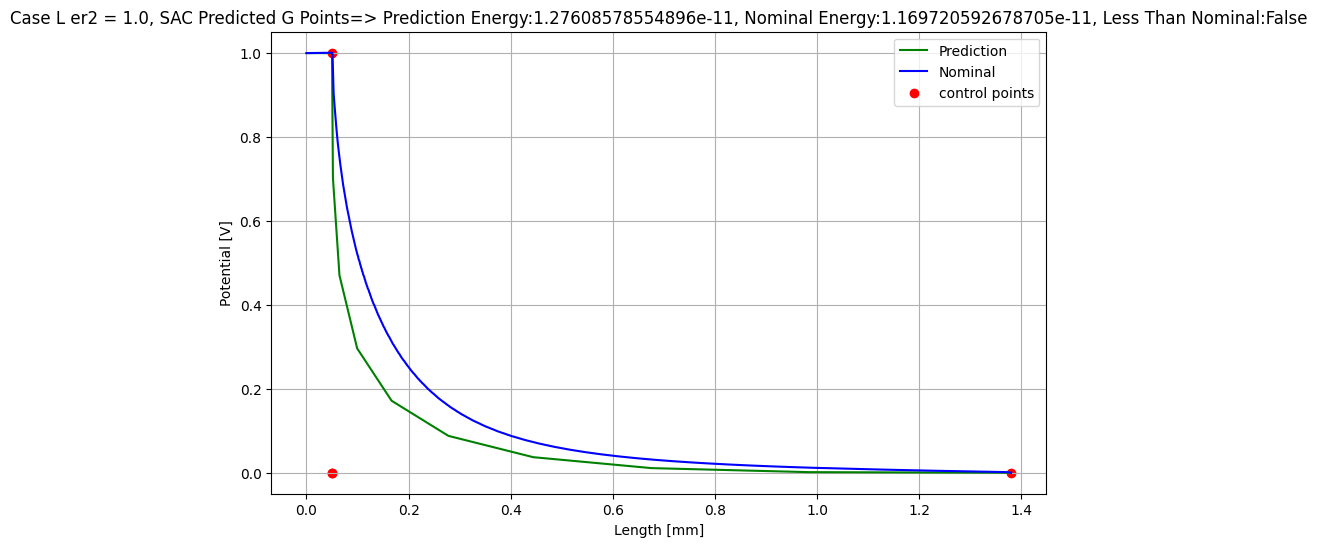

In [10]:
# plot
######################################################################################################
env_L = msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=2.76e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=1.0,num_fs=500,num_pts=10)
obs_space,_ss = env_L.reset()
# action_caseL, _states = model.predict(obs_space)
g_ptsx,g_ptsy,control_points = env_L.g_points_cubic_bezier(np.array([0,0,0,0]))
print(f'Montone Decreasing: {env_L.monotonically_decreasing(g_ptsy)}, Convex: {env_L.is_convex(g_ptsy)}')
# print(f'Action A2C: {action_caseL}')
g_ptsx = np.insert(g_ptsx,0,0)
g_ptsy = np.insert(g_ptsy,0,1)

Energy_pred = env_L.energy(env_L.potential_coeff(g_ptsy[2:-1],g_ptsx[2:-1]))
Energy_nom = env_L.energy(env_L.potential_coeff(y_true[2:-1],x_true[2:-1]))
Min_Energy = Energy_pred < Energy_nom

print(f'Prediction Energy:{Energy_pred}')

# Plot 
plt.figure(figsize=(10, 6))
plt.plot(g_ptsx*1000, g_ptsy, color = 'green',label='Prediction')
plt.plot(x_true*1000, y_true, color = 'blue',label='Nominal')
plt.scatter(control_points[:,0]*1000,control_points[:,1],color='red',label='control points')
# plt.plot(env_L.x*1000, env_L.line_threshold, color = 'brown',label='Threshold')
plt.title(f'Case L er2 = 1.0, SAC Predicted G Points=> Prediction Energy:{Energy_pred}, Nominal Energy:{Energy_nom}, Less Than Nominal:{Min_Energy}')
plt.xlabel('Length [mm]')
plt.ylabel('Potential [V]')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
SAC_res = {'g_ptsx':g_ptsx,
           'g_ptsy':g_ptsy
           }
(pd.DataFrame(SAC_res)).to_csv('training/cubic_bezier_curve_CaseL_SAC.csv')

#### A2C

In [ ]:
# setting up the MSA env with number of fs_coeff = 500
env_L = msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=2.76e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=1.0,num_fs=500,num_pts=20)

# # number of parallel environments
# num_envs = 8

# # VecEnv for separate-process parallelization
# vectorized_env = DummyVecEnv([lambda: msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=1.38e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=1.0,num_fs=20,num_pts=20)
#                               for _ in range(num_envs)])

# set a different environment for evaluation
eval_env = msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=2.76e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=1.0,num_fs=500,num_pts=20)

#### Setup Model and Train

In [ ]:
# Specify directories
#################################################################################################
models_dir = os.path.join(models_dir_root,'Case_L','A2C')
logdir = os.path.join(logdir_root,'Case_L','A2C')
imgdir = os.path.join(imgdir_root,'Case_L','A2C')

for dir in [models_dir,logdir,imgdir]:
    if not os.path.exists(dir):
        os.makedirs(dir)


# Specify hyperparameters
##################################################################################################
# setting nn architecture
policy_kwargs = dict(activation_fn=th.nn.ReLU,
                     net_arch=[64, 64])
hyperparams = {
    'ent_coef': 0.1,            # Entropy coefficient
    'learning_rate': 0.0007,     # Learning rate
    'gae_lambda': 0.95,          # Generalized Advantage Estimation lambda
    'gamma': 0.99,               # Discount factor
    'max_grad_norm': 0.5,        # Maximum gradient norm

}
1
# set the total steps to be taken during model learning
TIMESTEPS = 20000 # one hundred thousand timesteps

# verbose = 1 prints details
# does not support batch size, action noise parameter
# 
# action_noise=action_noise, 
# batch_size=hyperparams["batch_size"],
# model
#####################################################################################################
# model = A2C("MlpPolicy", 
#              vectorized_env,  
#              verbose=0, 
#              policy_kwargs=policy_kwargs,
#              tensorboard_log=os.path.join(logdir,'A2C'),
#              **hyperparams)

model = A2C("MlpPolicy", 
             env_L,  
             verbose=0, 
             ent_coef = 0.05,
             tensorboard_log=os.path.join(logdir,'A2C'))
model,caseL_res,action_caseL = F.train_model('A2C',model,env_L,'Case_L',TIMESTEPS,x_true,y_true,models_dir,imgdir)

# print action
print(f'Action A2C: {action_caseL}')

# Evaluate the trained agent
######################################################################################################
mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=10)
print(f"Mean reward: {mean_reward} +/- {std_reward:.2f}")

#### Plot

In [ ]:
# plot
######################################################################################################
env_L = msaEnv(V0=1,hw_arra=1.38e-3,ht_arra=2.76e-3,ht_subs=0.1382e-3,hw_micrstr=0.05e-3,ht_micrstr=0,er_1=1.0,er_2=1.0,num_fs=500,num_pts=10)
obs_space,_ss = env_L.reset()
action_caseL, _states = model.predict(obs_space)
g_ptsx,g_ptsy,control_points = env_L.g_points_cubic_bezier(action_caseL)
print(f'Montone Decreasing: {env_L.monotonically_decreasing(g_ptsy)}, Convex: {env_L.is_convex(g_ptsy)}')
print(f'Action A2C: {action_caseL}')
g_ptsx = np.insert(g_ptsx,0,0)
g_ptsy = np.insert(g_ptsy,0,1)

Energy_pred = env_L.energy(env_L.potential_coeff(g_ptsy[2:-1],g_ptsx[2:-1]))
Energy_nom = env_L.energy(env_L.potential_coeff(y_true[2:-1],x_true[2:-1]))

print(f'Prediction Energy:{Energy_pred}')

# Plot 
plt.figure(figsize=(10, 6))
plt.plot(g_ptsx*1000, g_ptsy, color = 'green',label='Prediction')
plt.plot(x_true*1000, y_true, color = 'blue',label='Nominal')
plt.scatter(control_points[:,0]*1000,control_points[:,1],color='red',label='control points')
# plt.plot(env_L.x*1000, env_L.line_threshold, color = 'brown',label='Threshold')
plt.title(f'Case L er2 = 1.0, A2C Predicted G Points=> Prediction Energy:{Energy_pred}, Nominal Energy:{Energy_nom}')
plt.xlabel('Length [mm]')
plt.ylabel('Potential [V]')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
A2C_res = {'g_ptsx':g_ptsx,
           'g_ptsy':g_ptsy
           }
(pd.DataFrame(A2C_res)).to_csv('training/cubic_bezier_curve_CaseL_A2C.csv')

### Impedance, Phase Velocity

In [ ]:
# c0 = 299792458 # speed of light in vacuum (m/s)

# Zd_pred = 1/(c0*(caseD_res['Capacitance']*caseL_res['Capacitance'])**0.5)
# Zd_nom = 1/(c0*(caseD_res['Capacitance_True']*caseL_res['Capacitance_True'])**0.5)

# Zl_pred = 1/(c0*caseL_res['Capacitance'])
# Zl_nom = 1/(c0*caseL_res['Capacitance_True'])

# eps_eff_pred = caseD_res['Capacitance']/caseL_res['Capacitance']
# eps_eff_nom = caseD_res['Capacitance_True']/caseL_res['Capacitance_True']

# velocity_phase_pred = c0/(eps_eff_pred**0.5)
# velocity_phase_nom = c0/(eps_eff_nom**0.5)

# print(f'''
#       Characteristic Impedance Case D prediction :{Zd_pred}
#       Characteristic Impedance Case D nominal:{Zd_nom}
      
#       Characteristic Impedance Case L prediction :{Zl_pred}
#       Characteristic Impedance Case L nominal :{Zl_nom}
      
#       Effective dielectric constant prediction :{eps_eff_pred}
#       Effective dielectric constant nominal :{eps_eff_nom}
      
#       electron phase velocity pred :{velocity_phase_pred}
#       electron phase velocity nom :{velocity_phase_nom}''')

In [ ]:
# Result = {
#     'Zd_pred':Zd_pred,
#     'Zd_nom':Zd_nom,
#     'Zl_pred':Zl_pred,
#     'Zl_nom':Zl_nom,
#     'eps_eff_pred':eps_eff_pred,
#     'eps_eff_nom':eps_eff_nom,
#     'phase_velocity_pred':velocity_phase_pred,
#     'phase_velocity_nom':velocity_phase_nom
# }

# (pd.DataFrame(Result,index=[0])).to_csv('training/cubic_bezier_curve_Impedance_Result.csv', index=False)

# Useful Stuff

In [ ]:
# import scipy.io
# mat = scipy.io.loadmat('data22samp.mat')

In [ ]:
# import sys
# import traceback

# # number of parallel environments
# num_envs = 4

# def init_env():
#     try:
#         return msaEnv(V0=1, hw_arra=1.38e-3, ht_arra=1.38e-3, ht_subs=0.1382e-3, hw_micrstr=0.05e-3, ht_micrstr=0, er_1=1.0, er_2=12.9, num_fs=20, num_pts=20)
#     except Exception as e:
#         traceback.print_exc(file=sys.stdout)
#         sys.stdout.flush()
#         raise e

# env = SubprocVecEnv([init_env for _ in range(num_envs)])

# import pickle

# def is_picklable(obj):
#     try:
#         pickle.dumps(obj)
#         return True
#     except Exception as e:
#         print(f"Error: {e}")
#         return False

# # Example usage
# class PicklableObject:
#     pass

# # Check picklability of an instance of PicklableObject
# obj = PicklableObject()
# result = is_picklable(obj)
# print(f"Is picklable: {result}")

In [ ]:
# %%timeit
# a = [2,5,6,9,8,7,4,10,1,3]

# for i in range(0,len(a)-1):
#     for j in range(0,len(a)-1):
#         if a[j]<=a[j+1]:
#             temp = a[j]
#             a[j] = a[j+1]
#             a[j+1] = temp     
        